In [2]:
import pandas as pd
import numpy as np

from sentence_transformers import SentenceTransformer
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib
import os


c:\Projects\Code-Mixed-Hate-Speech-Detection-in-Sinhala-Tamil-English\hate_speech_project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
#Load Splits
train_df = pd.read_csv("../data/processed/train.csv")
val_df   = pd.read_csv("../data/processed/val.csv")
test_df  = pd.read_csv("../data/processed/test.csv")

X_train = train_df["Comment_clean"].tolist()
y_train = train_df["Label_id"]

X_val = val_df["Comment_clean"].tolist()
y_val = val_df["Label_id"]

X_test = test_df["Comment_clean"].tolist()
y_test = test_df["Label_id"]


In [4]:
#Load Multilingual Embedding Model
model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 295.54it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [5]:
#Generate Embeddings (Batch-wise)
X_train_emb = model.encode(X_train, batch_size=32, show_progress_bar=True)
X_val_emb   = model.encode(X_val, batch_size=32, show_progress_bar=True)
X_test_emb  = model.encode(X_test, batch_size=32, show_progress_bar=True)



Batches: 100%|██████████| 223/223 [02:45<00:00,  1.35it/s]


In [6]:
#Save Embeddings
np.save("../models/train_embeddings.npy", X_train_emb)
np.save("../models/val_embeddings.npy", X_val_emb)
np.save("../models/test_embeddings.npy", X_test_emb)


In [7]:
#Train Cost-Sensitive SVM (RBF Kernel)
best_f1 = 0
best_model = None
best_c = None

for c in [0.1, 1, 5, 10]:
    
    svm = SVC(
        kernel="linear",
        class_weight="balanced",
        C=c
    )
    
    svm.fit(X_train_emb, y_train)
    
    val_pred = svm.predict(X_val_emb)
    
    report = classification_report(y_val, val_pred, output_dict=True)
    macro_f1 = report["macro avg"]["f1-score"]
    
    print(f"C={c} → Macro F1: {macro_f1:.4f}")
    
    if macro_f1 > best_f1:
        best_f1 = macro_f1
        best_model = svm
        best_c = c

print("\nBest C:", best_c)
print("Best Validation Macro F1:", best_f1)


C=0.1 → Macro F1: 0.6383
C=1 → Macro F1: 0.6400
C=5 → Macro F1: 0.6392
C=10 → Macro F1: 0.6392

Best C: 1
Best Validation Macro F1: 0.6400174297370559


In [8]:
#Evaluate
y_test_pred = best_model.predict(X_test_emb)

print("Hybrid Model (Embeddings + Linear SVM Balanced)")
print(classification_report(y_test, y_test_pred, target_names=["NON_HATE", "HATE"]))



Hybrid Model (Embeddings + Linear SVM Balanced)
              precision    recall  f1-score   support

    NON_HATE       0.93      0.68      0.78      5673
        HATE       0.39      0.80      0.52      1458

    accuracy                           0.70      7131
   macro avg       0.66      0.74      0.65      7131
weighted avg       0.82      0.70      0.73      7131



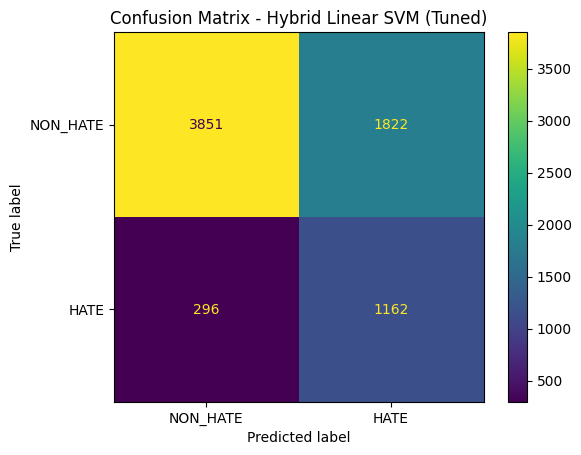

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["NON_HATE", "HATE"]
)

disp.plot()
plt.title("Confusion Matrix - Hybrid Linear SVM (Tuned)")
plt.savefig("../results/hybrid_linear_tuned_confusion_matrix.png")
plt.show()



In [10]:
report_text = classification_report(
    y_test,
    y_test_pred,
    target_names=["NON_HATE", "HATE"]
)

accuracy = accuracy_score(y_test, y_test_pred)

with open("../results/hybrid_linear_tuned_results.txt", "w", encoding="utf-8") as f:
    f.write("=== Hybrid Model (Embeddings + Linear SVM Balanced Tuned) ===\n\n")
    f.write(report_text)
    f.write("\n\nBest C: {}\n".format(best_c))
    f.write("Accuracy: {:.4f}\n".format(accuracy))
    f.write("\nConfusion Matrix:\n")
    f.write(str(cm))

